## Imports
All necessary imports are done at the start of the notebook in order to keep the file systematic and clean.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Data Loading

First the training, test, and sample submission files are loaded from the Kaggle Input directory.

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

train_df = pd.read_csv('/kaggle/input/house-price-prediction-iitm/estate_train.csv')
test_df = pd.read_csv('/kaggle/input/house-price-prediction-iitm/estate_test.csv')
sample_submission = pd.read_csv('/kaggle/input/house-price-prediction-iitm/estate_sample_submission.csv')

/kaggle/input/house-price-prediction-iitm/estate_train.csv
/kaggle/input/house-price-prediction-iitm/estate_sample_submission.csv
/kaggle/input/house-price-prediction-iitm/estate_test.csv


## Basic Information

This section displays the structure of the training dataset.  
It includes the column names, data types, and non-null counts to help understand the overall shape and completeness of the data.


In [3]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IncomeLevel        16512 non-null  float64
 1   PropertyAge        15199 non-null  float64
 2   TotalRooms         16512 non-null  float64
 3   TotalBedrooms      16512 non-null  float64
 4   NeighborhoodPop    16512 non-null  float64
 5   AvgOccupancy       16512 non-null  float64
 6   Latitude           16512 non-null  float64
 7   Longitude          16512 non-null  float64
 8   TargetPrice        16512 non-null  float64
 9   PropertyID         16512 non-null  object 
 10  RoomsPerHousehold  16512 non-null  float64
 11  BedroomsRatio      16512 non-null  float64
dtypes: float64(11), object(1)
memory usage: 1.5+ MB
None


In [4]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IncomeLevel        4128 non-null   float64
 1   PropertyAge        3773 non-null   float64
 2   TotalRooms         4128 non-null   float64
 3   TotalBedrooms      4128 non-null   float64
 4   NeighborhoodPop    4128 non-null   float64
 5   AvgOccupancy       4128 non-null   float64
 6   Latitude           4128 non-null   float64
 7   Longitude          4128 non-null   float64
 8   PropertyID         4128 non-null   object 
 9   RoomsPerHousehold  4128 non-null   float64
 10  BedroomsRatio      4128 non-null   float64
dtypes: float64(10), object(1)
memory usage: 354.9+ KB
None


In [5]:
print(sample_submission.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PropertyID   4128 non-null   object 
 1   TargetPrice  4128 non-null   float64
dtypes: float64(1), object(1)
memory usage: 64.6+ KB
None


## Descriptive Statistics


In [6]:
display(train_df.describe())

,IncomeLevel,PropertyAge,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,TargetPrice,RoomsPerHousehold,BedroomsRatio
count,16512.000000,15199.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880870,28.610537,5.435311,1.096797,1426.441888,3.097123,35.643149,-119.582290,2.071947,1.980582,0.212858
std,1.906229,12.604955,2.387346,0.433573,1137.594296,11.589701,2.136665,2.005654,1.156226,1.125818,0.057995
min,0.409295,0.567139,0.973695,0.329765,-44.578990,0.579087,32.550000,-124.350000,0.149990,0.002547,0.100000
25%,2.564153,18.195306,4.450483,1.005528,788.555955,2.362349,33.930000,-121.810000,1.198000,1.526243,0.175178
50%,3.544769,28.747429,5.238836,1.049505,1169.707835,2.835532,34.260000,-118.510000,1.798500,1.941541,0.202808
75%,4.779065,37.045296,6.064049,1.102542,1730.584980,3.364962,37.720000,-118.010000,2.651250,2.300615,0.239501
max,15.113356,53.490497,141.875493,25.630214,35739.248210,1243.662159,41.950000,-114.310000,5.000010,52.033333,1.000000


In [7]:
display(test_df.describe())

,IncomeLevel,PropertyAge,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,RoomsPerHousehold,BedroomsRatio
count,4128.000000,3773.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.00000,4128.00000,4128.000000,4128.000000
mean,3.830719,28.682060,5.401898,1.096816,1421.374588,2.966576,35.58671,-119.51936,1.962518,0.213941
std,1.883274,12.494979,2.796817,0.610529,1115.473556,1.755270,2.13276,1.99447,1.223534,0.058135
min,0.530203,0.715202,0.813320,0.510180,-37.000397,1.236617,32.54000,-124.19000,0.061605,0.108164
25%,2.554915,18.259809,4.386189,1.002786,781.260054,2.432482,33.93000,-121.69000,1.511737,0.176204
50%,3.486886,29.027066,5.184169,1.046765,1161.163505,2.818464,34.23000,-118.47000,1.925748,0.204279
75%,4.661292,37.123820,6.011166,1.099233,1726.571176,3.296391,37.70000,-117.99000,2.277103,0.240804
max,15.095812,52.829456,132.566404,34.063426,16116.561421,83.223442,41.81000,-114.58000,55.222222,1.000000


In [8]:
num_feature = train_df.select_dtypes(include = ['int64' , 'float64']).columns
print("Numerical Columns:",num_feature)

cat_feature = train_df.select_dtypes(include = ['object']).columns
print("Categorical Columns:",cat_feature)

Numerical Columns: Index(['IncomeLevel', 'PropertyAge', 'TotalRooms', 'TotalBedrooms',
       'NeighborhoodPop', 'AvgOccupancy', 'Latitude', 'Longitude',
       'TargetPrice', 'RoomsPerHousehold', 'BedroomsRatio'],
      dtype='object')
Categorical Columns: Index(['PropertyID'], dtype='object')


## Checking for Missing Values and Duplicates

Before we begin preprocessing, it's important to check for any missing values or duplicate rows in the dataset.  
This helps us understand if any cleaning is required before model training.


In [9]:
print(f"\nMissing values in Training Data:\n{train_df.isnull().sum()}")
print(f"\nDuplicates in Training Dataset: {train_df.duplicated().sum()}")


Missing values in Training Data:
IncomeLevel             0
PropertyAge          1313
TotalRooms              0
TotalBedrooms           0
NeighborhoodPop         0
AvgOccupancy            0
Latitude                0
Longitude               0
TargetPrice             0
PropertyID              0
RoomsPerHousehold       0
BedroomsRatio           0
dtype: int64

Duplicates in Training Dataset: 0


In [10]:
print(f"\nMissing values in Test Data:\n{test_df.isnull().sum()}")
print(f"\nDuplicates in Test Dataset: {test_df.duplicated().sum()}")


Missing values in Test Data:
IncomeLevel            0
PropertyAge          355
TotalRooms             0
TotalBedrooms          0
NeighborhoodPop        0
AvgOccupancy           0
Latitude               0
Longitude              0
PropertyID             0
RoomsPerHousehold      0
BedroomsRatio          0
dtype: int64

Duplicates in Test Dataset: 0


In [11]:
print(f"\nMissing values in Sample Submission Data:\n{sample_submission.isnull().sum()}")
print(f"\nDuplicates in Sample Submission Dataset: {sample_submission.duplicated().sum()}")


Missing values in Sample Submission Data:
PropertyID     0
TargetPrice    0
dtype: int64

Duplicates in Sample Submission Dataset: 0


## Visualizing Missing Values

To better understand the data quality, we plot a heatmap showing the locations of missing values in the dataset.  
This gives a quick visual overview of where data might be incomplete.


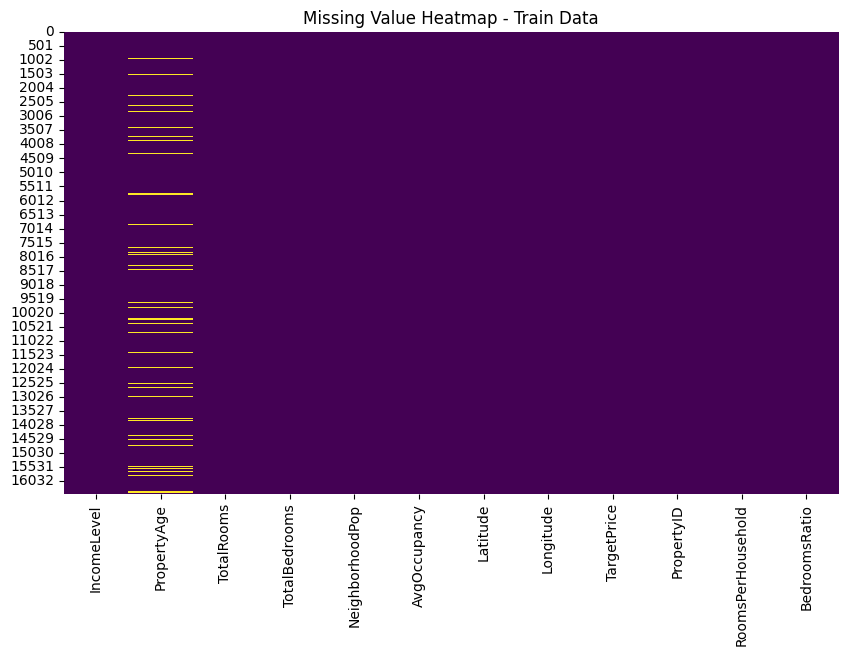

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap - Train Data")
plt.show()

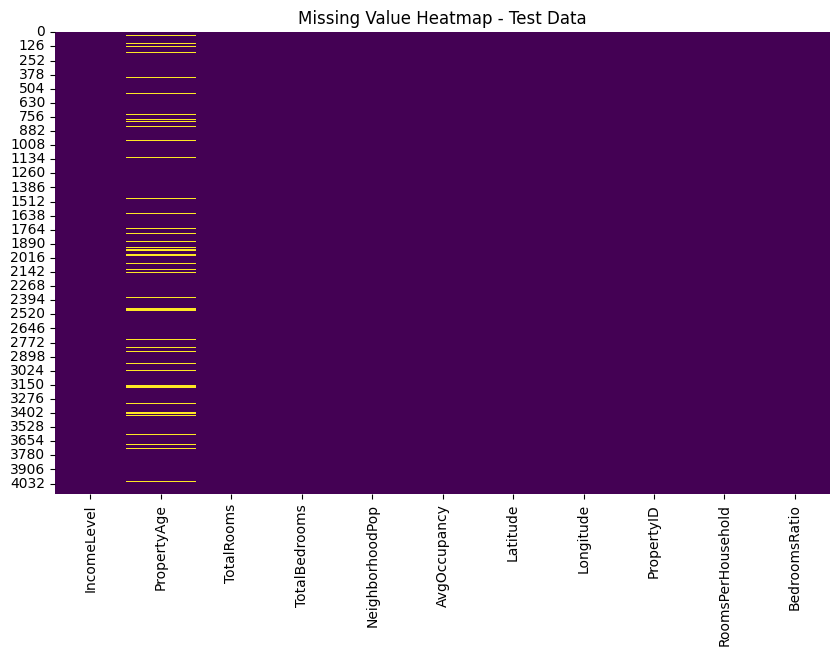

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(test_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap - Test Data")
plt.show()

## Warning Handling

As I progressed with the notbook,I saw kaggle notbook issuing some warnings.So, I later on turned of warnings with python warnings library in order to keep notebook clean.


In [14]:
import warnings
warnings.filterwarnings("ignore")

## Price Distribution

We plot a histogram of the `price` column to understand how prices are distributed in the training dataset.  
This helps identify skewness, outliers, or any unusual patterns in the target variable.


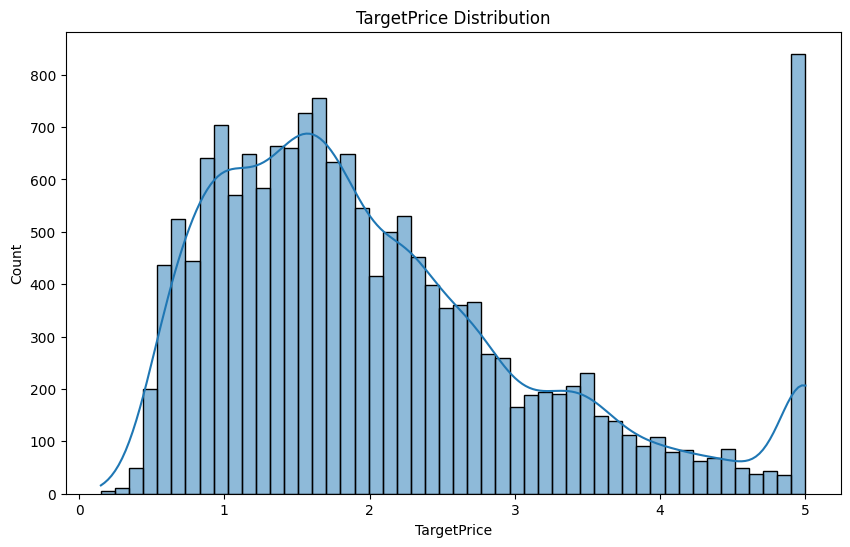

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(train_df['TargetPrice'], bins=50, kde=True)
plt.title('TargetPrice Distribution')
plt.show()

## Houses by Property Age

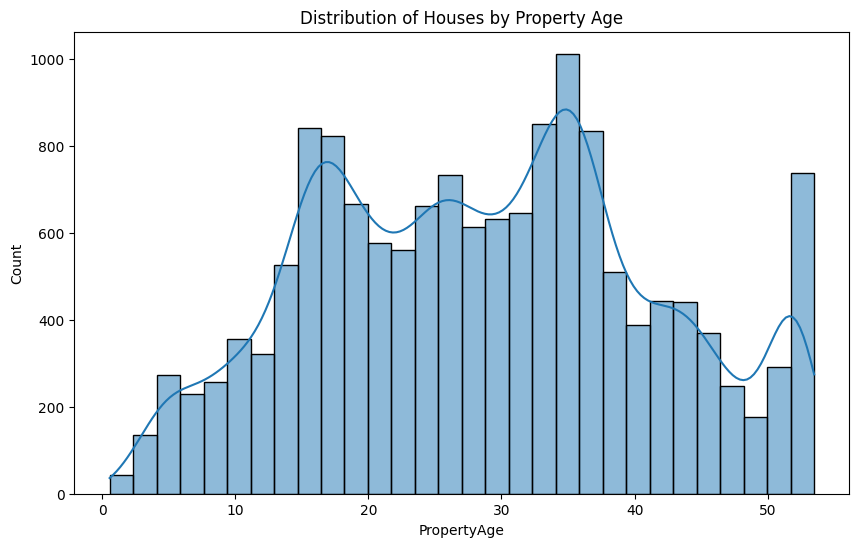

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data=train_df, x='PropertyAge', bins=30, kde=True)
plt.title('Distribution of Houses by Property Age')
plt.show()

## Property Age vs Target Price

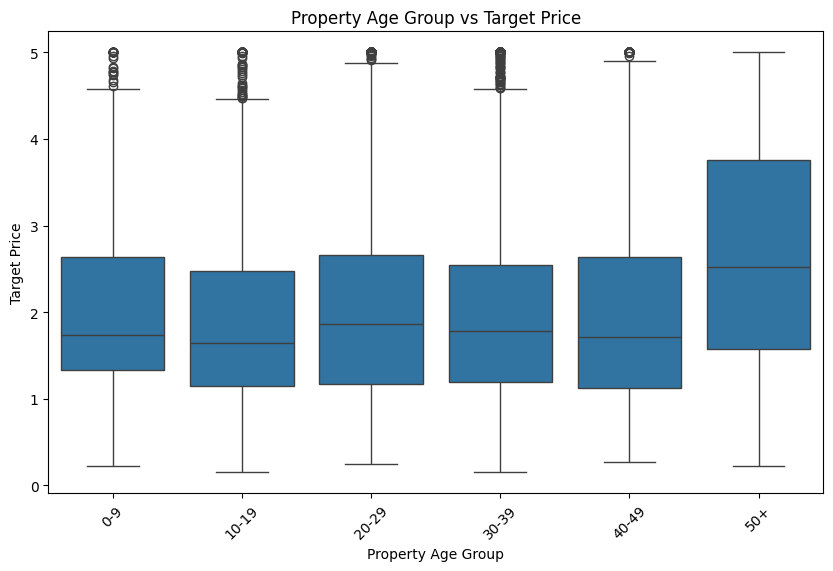

In [17]:
temp_train_df = train_df.copy()
bins = [0, 10, 20, 30, 40, 50, 60]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50+']
temp_train_df['PropertyAgeGroup'] = pd.cut(temp_train_df['PropertyAge'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10,6))
sns.boxplot(data=temp_train_df, x='PropertyAgeGroup', y='TargetPrice')
plt.title('Property Age Group vs Target Price')
plt.xticks(rotation=45)
plt.xlabel('Property Age Group')
plt.ylabel('Target Price')
plt.show()

## Total Rooms Vs Target Price

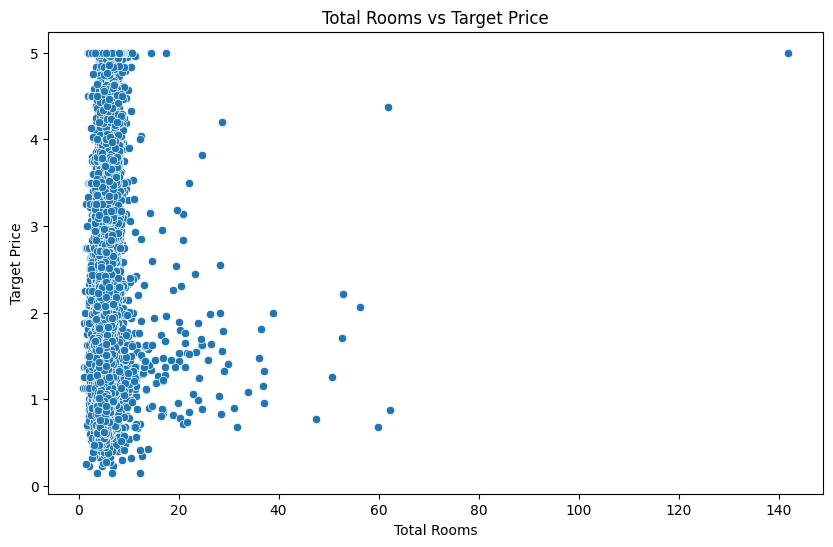

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=train_df, x='TotalRooms', y='TargetPrice')
plt.title('Total Rooms vs Target Price')
plt.xlabel('Total Rooms')
plt.ylabel('Target Price')
plt.show()

## Correlation Heatmap

This heatmap shows how different numerical features in the dataset are related to each other.  
It helps identify which features have strong positive or negative relationships, useful for understanding the data better before modeling.


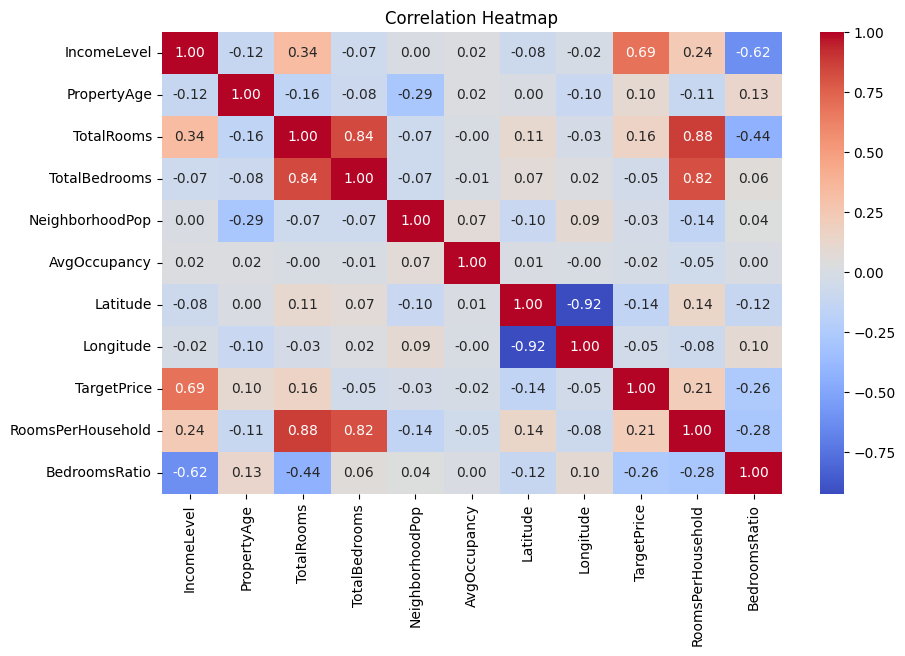

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm',fmt='0.2f')
plt.title("Correlation Heatmap")
plt.show()

## Handling Missing Values and Outliers

Missing values in numerical columns like `total_sqft`, `bath`, and `balcony` are filled using K-Nearest Neighbors (KNN) imputation.\
To improve model accuracy, outliers in `price` are removed using the Interquartile Range (IQR) method.\
This helps in cleaning the dataset and reducing the effect of extreme values.

In [20]:
target_col = "TargetPrice"
X = train_df.drop(columns=[target_col, 'PropertyID'])
y = np.log1p(train_df[target_col]) 

X['PropertyAge'] = X['PropertyAge'].fillna(X['PropertyAge'].median())
test_df['PropertyAge'] = test_df['PropertyAge'].fillna(X['PropertyAge'].median())

def add_features(df):
    df['total_rooms_per_pop'] = df['TotalRooms'] / (df['NeighborhoodPop'] + 1)
    df['bedroom_per_room'] = df['TotalBedrooms'] / (df['TotalRooms'] + 1)
    df['location_sum'] = df['Latitude'] + df['Longitude']
    return df

X = add_features(X)
X_test = add_features(test_df.drop(columns=['PropertyID']))

### Handling of Duplicate Values
As checked earlier training dataset does not have missing values so handling is not needed

## Encoding and Feature Scaling


In [21]:
features = X.columns.tolist()

scaler = StandardScaler()
X[features] = scaler.fit_transform(X[features])
X_test[features] = scaler.transform(X_test[features])

## Splitting the Data

The dataset is split into training and validation sets.  
80% of the data is used to train the models, and 20% is kept aside to test how well the models perform on unseen data.  
This helps in evaluating the model's ability to generalize.


In [22]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Evaluation Function

This function is used to assess the performance of a trained model.

It computes two key metrics:
- **Root Mean Squared Error (RMSE)**: Measures the average magnitude of the errors. A lower value indicates better accuracy.
- **R-squared (R²)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A value closer to 1 suggests a better fit.

The function prints these results and returns them for easy comparison between different models.

In [23]:
def assess_model_performance(y_true, y_pred, name):
    root_mean_squared_error = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_score_value = r2_score(y_true, y_pred)
    mean_absolute_error_value = mean_absolute_error(y_true, y_pred)
    print(f"{name}: RMSE = {root_mean_squared_error:.2f}, MAE = {mean_absolute_error_value:.2f}, R² = {r2_score_value:.4f}")
    return root_mean_squared_error, mean_absolute_error_value, r2_score_value

# AI Model Training and hypertuning

## Model Storage

We initialize two empty dictionaries:
- `trained_models` will hold our trained machine learning models.
- `performance_metrics` will store their evaluation results.

This setup allows us to organize and compare the performance of each model.

In [24]:
trained_models = {}
performance_metrics = {}

## Training

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=22, min_samples_split=4, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=220, max_depth=5, random_state=42
    ),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(
        n_estimators=220, max_depth=5, learning_rate=0.1, random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    rmse, mae, r2 = assess_model_performance(y_val, y_pred_val, name)
    trained_models[name] = model
    performance_metrics[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

Linear Regression: RMSE = 0.21, MAE = 0.16, R² = 0.6721
Ridge Regression: RMSE = 0.21, MAE = 0.16, R² = 0.6722
Decision Tree: RMSE = 0.19, MAE = 0.13, R² = 0.7246
Random Forest: RMSE = 0.14, MAE = 0.10, R² = 0.8393
Gradient Boosting: RMSE = 0.14, MAE = 0.10, R² = 0.8465
SVR: RMSE = 0.16, MAE = 0.12, R² = 0.7907
KNN: RMSE = 0.17, MAE = 0.12, R² = 0.7838
XGBoost: RMSE = 0.14, MAE = 0.10, R² = 0.8515


## Models with Hyperparameter Tuning

Hyperparameter tuning using Grid Search was performed on the following models:

*   Random Forest
*   Gradient Boosting
*   XGBoost

### Random Forest Tuning (Randomized Search)

We will perform hyperparameter tuning for the Random Forest Regressor using `RandomizedSearchCV` to find the best combination of parameters for improved performance.

In [26]:
# rf_params = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [12, 16, 22, None],
#     'min_samples_split': [2, 4, 8],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf_search = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42),
#     rf_params,
#     n_iter=10,
#     cv=3,
#     scoring='r2',
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# rf_search.fit(X[features], y)

# print("Best RF Params:", rf_search.best_params_)

### Gradient Boosting Tuning (Randomized Search)

We will perform hyperparameter tuning for the Gradient Boosting Regressor using `RandomizedSearchCV` to find the best combination of parameters.

In [27]:
# gb_params = {
#     'n_estimators': [100, 220, 300],
#     'learning_rate': [0.01, 0.08, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.7, 1.0]
# }

# gb_search = RandomizedSearchCV(
#     GradientBoostingRegressor(random_state=42),
#     gb_params,
#     n_iter=10,
#     cv=3,
#     scoring='r2',
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )
# gb_search.fit(X[features], y)

# print("Best GB Params:", gb_search.best_params_)

### XGBoost Tuning (Randomized Search)

We will perform hyperparameter tuning for the XGBoost Regressor using `RandomizedSearchCV` to find the best combination of parameters.

In [28]:
# xgb_params = {
#     'n_estimators': [100, 220, 300],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'max_depth': [3, 5, 7, 10],
#     'subsample': [0.7, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0]
# }

# xgb_search = RandomizedSearchCV(
#     XGBRegressor(random_state=42),
#     xgb_params,
#     n_iter=10,
#     cv=3,
#     scoring='r2',
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# xgb_search.fit(X[features], y)

# print("Best XGB Params:", xgb_search.best_params_)

## Hypertuned model Training

In [29]:
hypertuned_models= {
    "Random Forest_new": RandomForestRegressor(n_estimators=300, min_samples_split=4, min_samples_leaf=2, random_state=42, max_depth= 22),
    "Gradient Boosting_new": GradientBoostingRegressor(n_estimators=300, max_depth=7, learning_rate=0.08, random_state=42,subsample=0.7),
    "XGBoost_new": XGBRegressor(n_estimators=300, subsample=0.7,max_depth=7, learning_rate=0.1, colsample_bytree=1.0, random_state=42)
}

for name, model in hypertuned_models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    rmse, mae, r2 = assess_model_performance(y_val, y_pred_val, name)
    performance_metrics[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    trained_models[name] = model

Random Forest_new: RMSE = 0.14, MAE = 0.10, R² = 0.8394
Gradient Boosting_new: RMSE = 0.14, MAE = 0.09, R² = 0.8518
XGBoost_new: RMSE = 0.14, MAE = 0.09, R² = 0.8567


## Model Comparison

After training all models, we compare them using three key metrics:
- **Root Mean Squared Error (RMSE)**: Measures the average magnitude of the errors. Lower is better.
- **Mean Absolute Error (MAE)**: Measures the average magnitude of the errors without considering their direction. Lower is better.
- **R² Score**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher is better, as it shows how well the model explains the variance in the data.

This helps us identify which model performs best overall.

In [30]:
results_df = pd.DataFrame(performance_metrics, index=['RMSE', 'MAE', 'R2']).T.sort_values(by='RMSE', ascending=True)
print("\nModel Comparison:")
print(results_df)


Model Comparison:
                           RMSE       MAE        R2
XGBoost_new            0.135875  0.093859  0.856718
Gradient Boosting_new  0.138166  0.094277  0.851847
XGBoost                0.138351  0.095602  0.851451
Gradient Boosting      0.140629  0.097705  0.846518
Random Forest_new      0.143862  0.098815  0.839380
Random Forest          0.143892  0.098817  0.839312
SVR                    0.164241  0.118654  0.790652
KNN                    0.166902  0.119912  0.783812
Decision Tree          0.188360  0.126454  0.724650
Ridge Regression       0.205534  0.155712  0.672151
Linear Regression      0.205534  0.155707  0.672148


# Final Model and Submission

The chosen model is retrained using the full training and validation sets to maximize learning.
Finally, we make predictions on the test data and prepare the submission file.

In [31]:
best_model_name = results_df.index[0]
print(f"\nChoosing {best_model_name} as final model based on RMSE score.")

final_model = trained_models[best_model_name]

print("Retraining chosen model on the full training data...")
final_model.fit(X[features], y)

print("Making predictions on the test data...")
test_pred = np.expm1(final_model.predict(X_test[features]))

submission = pd.DataFrame({
    'PropertyID': test_df['PropertyID'].values,
    'TargetPrice': test_pred
})
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'!")


Choosing XGBoost_new as final model based on RMSE score.
Retraining chosen model on the full training data...
Making predictions on the test data...
Submission file saved as 'submission.csv'!


In [32]:
print(submission.head())

   PropertyID  TargetPrice
0  PROP_20046     0.489025
1  PROP_03024     0.639823
2  PROP_15663     5.792647
3  PROP_20484     2.313300
4  PROP_09814     2.657376
